In [1]:
##### notebook for running background processors and making plots

import awkward as ak
import numpy as np
import pickle
import hist
import coffea
from python.plugins import *
%matplotlib inline

# from hist import intervals
import matplotlib.pyplot as plt
import mplhep as hep
import matplotlib as mpl
plt.style.use([hep.style.CMS, hep.style.firamath])
hep.style.use("CMS")

In [2]:
from python.plotting import plotDataMC, plotDataMCwErrors
%load_ext autoreload

%autoreload 2

In [3]:
#### Booleans for deciding which plots to make live in this cell
dijet = True


In [4]:
if dijet:
    channel = "dijet"
    fname_z = "coffeaOutput/dijet/Zjets_dijetSel__fixSDmass_MG_2018.pkl"
    fname_w = "coffeaOutput/dijet/Wjets_dijetSel__fixSDmass_MG_2018.pkl"
    fname_tt = "coffeaOutput/dijet/TTbar_dijetSel__fixSDmass_MG_2018.pkl"
    fname_signal = "coffeaOutput/dijet/dijetHists_wXS_HTplots_QCDsim_rap2.5_MG_nominal__2018.pkl"
    fname_noxs = "coffeaOutput/dijet/dijetHists_noXS_HTplots_QCDsim_rap2.5_MG_nominal__2018.pkl"
    fname_data = "coffeaOutput/dijet/dijetHists_wXS_HTplots_JetHT_rap2.5_2018.pkl"
else:
    channel = 'trijet'
    fname_z = "coffeaOutput/trijet/Zjets_trijetSel__fixSDmass_MG_2018.pkl"
    fname_w = "coffeaOutput/trijet/Wjets_trijetSel__fixSDmass_MG_2018.pkl"
    fname_tt = "coffeaOutput/trijet/TTbar_trijetSel__fixSDmass_MG_2018.pkl"
    fname_signal = "coffeaOutput/trijet/trijetHists_addMETplots_QCDsim_rap2.5_MG_2018.pkl"
    fname_data = "coffeaOutput/dijet/dijetHists_fixSDmass_JetHT_rap2.5_2018.pkl"
if "all" in fname_z:
    year = "all"
elif "2018" in fname_z:
    year = "2018"
elif "2017" in fname_z:
    year = "2017"
elif "APV" in fname_z:
    year = "2016APV"
else:
    year = "2016"
with open(fname_signal, "rb") as f:
    result = pickle.load( f )
with open(fname_noxs, "rb") as f:
    result_noxs = pickle.load( f )
with open(fname_z, "rb") as f:
    result_z = pickle.load( f )
with open(fname_w, "rb") as f:
    result_w = pickle.load( f )
with open(fname_tt, "rb") as f:
    result_tt = pickle.load( f )
with open(fname_data, "rb") as f:
    result_data = pickle.load( f )
results = [result_z, result_tt, result]
result_str =["ZJets", "TTbar", "QCD"]
print(result_z["cutflow"])
cutflow = result["cutflow"]['/QCD_HpythiaMG2018']
print(cutflow.keys())

for key in cutflow.keys():
    if "sumw" in key:
        print(key, cutflow[key])
# print(result["cutflow"])

{'/ZJetspythiaMG2018': defaultdict(<class 'int'>, {'nEvents initial /ZJetsToNuNu_HT-800To1200_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAODSIM': 2129122, 'nEvents initial (all datasets)': 79861589, 'sumw for ZJetsToNuNu_HT-800To1200_TuneCP5_13TeV-madgraphMLM-pythia8': 2724.645004272461, 'nEvents initial nominal': 79861589, 'nEvents after gen rapidity selection ': 28219497, 'misses_u': 12357739, 'fakes_u': 208227, 'HEMveto': 9133213, 'nEvents failing softdrop condition': 0, 'nEvents weird (mreco>20, mgen<20) ungroomed events': 4383, 'nGluonJets': 5394022, 'nJets': 18266426, 'npv': 59041703, 'METfilters': 58973549, 'twoGenJet': 31802730, 'twoGenJet_seq': 31751332, 'genRap2p5': 28185249, 'genRap_seq': 28185249, 'dphiGen2': 28180491, 'genAsym0p3': 26904344, 'genDphi_seq': 25072102, 'genTot_seq': 21469475, 'twoRecoJet': 11635823, 'twoRecoJet_seq': 10440779, 'recoRap2p5': 10440764, 'recoRap_seq': 10440764, 'recodphi2': 9904621, 'r

[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan 0.         0.
 0.         0.         0.         0.         0.         0.
 0.01390971 0.46869821 1.03231997 1.31328146 1.40753346 1.41233185
 1.40228015 1.38935203 1.31183805 1.22481071 1.14505493 1.06700412
 1.00209942 0.94688286 0.91650966 0.86763405 0.84894686 0.84776493
 0.82099377 0.82111209 0.80879105 0.80451808 0.81598864 0.80732766
 0.80197067 0.80075647 0.79450568 0.78891258 0.79140345 0.78127892
 0.78009969 0.78531988 0.78818718 0.7811028  0.77739976 0.78023029
 0.77358245 0.780832   0.7720529  0.76348793 0.77206305 0.77125092
 0.77439091 0.77353165 0.76654208 0.77701485 0.77879261 0.76802172
 0.75914613 0.77969583 0.76426839 0.76868549 0.75820175 0.77193893
 0.76540453 0.76837648 0.76646367 0.76096851 0.76460751 0.75102878
 0.75815859 0.75491506 0.75973801 0.752052   0.76077263 0.76302178
 0.75008596 0.75592081 0.75652182 0.76199065 0.75918428 0.75418956
 0.74847696

Text(1, 0, 'HT (Gev)')

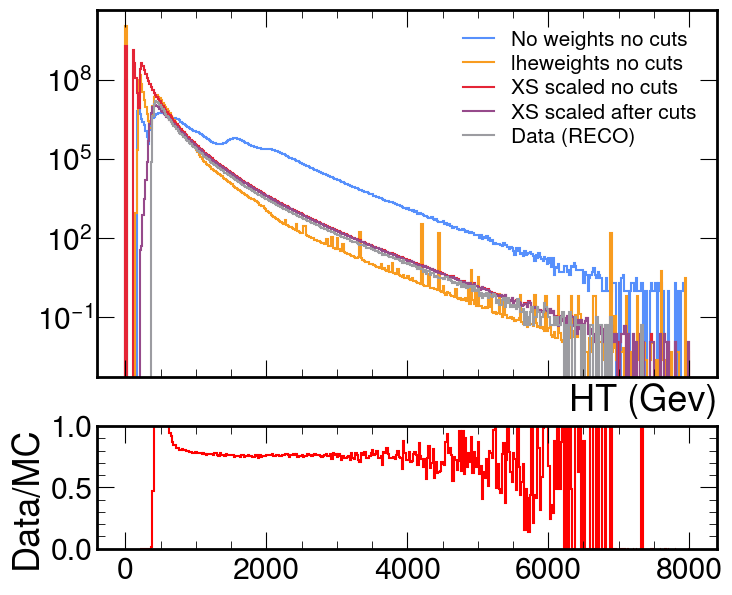

In [13]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
edges = [bin[0] for bin in result_noxs["HT_aftercuts"].project("pt").axes[0]] + [result_noxs["HT_aftercuts"].project('pt').axes[0][-1][1]]
hist = result_noxs['HT_nocuts'].project("pt").values()
hist1 = result_noxs["HT_wXS"][{'syst':'nominal'}].project("pt").values()
hist2 = result["HT_wXS"][{'syst':'nominal'}].project("pt").values()
hist3 = result["HT_aftercuts"][{'syst':'nominal'}].project("pt").values()
histdata = result_data["HT_aftercuts"][{'syst':'nominal'}].project("pt").values()
n_data = np.sum(histdata)
# hist1 = hist1*n_data/np.sum(hist1)
# hist = hist*n_data/np.sum(hist)
# hist2 = hist2*n_data/np.sum(hist2)
np.divide(histdata,hist2,
                          out=np.empty(np.array(histdata).shape).fill(np.nan),
                          where=hist2!= 0,)
ratio = histdata/hist3
print(ratio)
# ax.set_xlim(700,5000)
rax.set_ylim(0,1)
# ax.set_xscale('log')
ax.set_yscale('log')
hep.histplot(ratio, edges, ax=rax, stack=False, color='red')
hep.histplot(hist, edges, ax=ax, label = "No weights no cuts", stack=False)
hep.histplot(hist1, edges, binwnorm=True, label="lheweights no cuts", ax=ax, stack=False)
hep.histplot(hist2, edges, binwnorm=True, label="XS scaled no cuts", ax=ax, stack=False)
hep.histplot(hist3, edges, binwnorm=True, label="XS scaled after cuts", ax=ax, stack=False)
hep.histplot(histdata, edges, binwnorm=True, label="Data (RECO)", ax=ax, stack=False)
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("HT (Gev)")

Hist(
  StrCategory(['/QCD_HpythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown'], growth=True, name='syst', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=6.50625e+10, variance=1.08813e+13) (WeightedSum(value=6.50625e+10, variance=1.0

Text(1, 0, 'Ungroomed mass (Gev)')

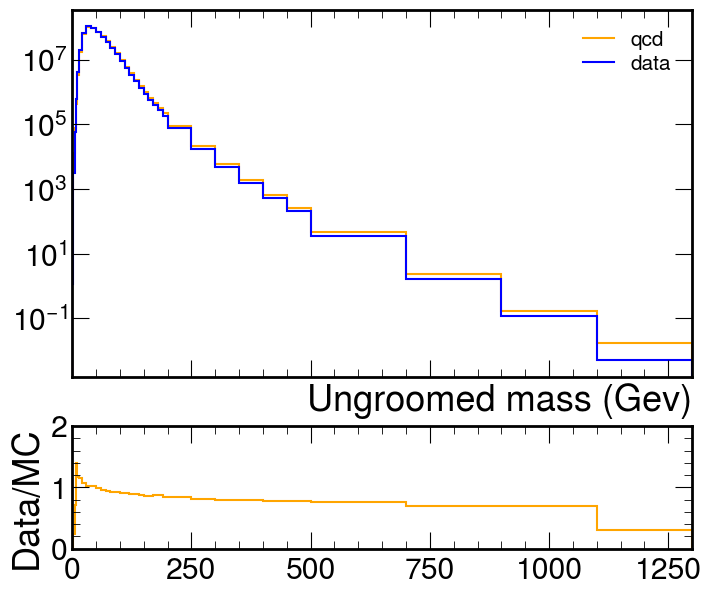

In [34]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["ptreco_mreco_u"].project("mreco").axes[0]] + [result["ptreco_mreco_u"].project('mreco').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").axes[0]] + [result["ptreco_mreco_u"].project('mreco').axes[0][-1][1]]
print(edges_data)
hist_data = result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
hist_mc = result["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
hist_noxs = result_noxs["ptreco_mreco_u"][{'syst':'nominal'}].project("mreco").values()
n_data = np.sum(hist_data)
hist_mc = hist_mc*n_data/np.sum(hist_mc)
hist_noxs = hist_noxs*n_data/np.sum(hist_noxs)
ratio = hist_data/hist_mc
ratio1 = hist_data/hist_noxs
ax.set_xlim(0,1300)
rax.set_ylim(0,2)
ax.set_yscale('log')
hep.histplot(ratio, edges,ax=rax, stack=False, color='orange')
# hep.histplot(ratio1, edges, ax=rax, stack=False, color='red')
hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False,color='orange')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False,color='blue')
# hep.histplot(hist_noxs, edges, binwnorm=True, label="qcd nxs", ax=ax, stack=False,color='red')
rax.set_ylabel("Data/MC")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
ax.set_xlabel("Ungroomed mass (Gev)")

Hist(
  StrCategory(['/QCD_HpythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown'], growth=True, name='syst', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=6.50625e+10, variance=1.08813e+13) (WeightedSum(value=6.50625e+10, variance=1.0

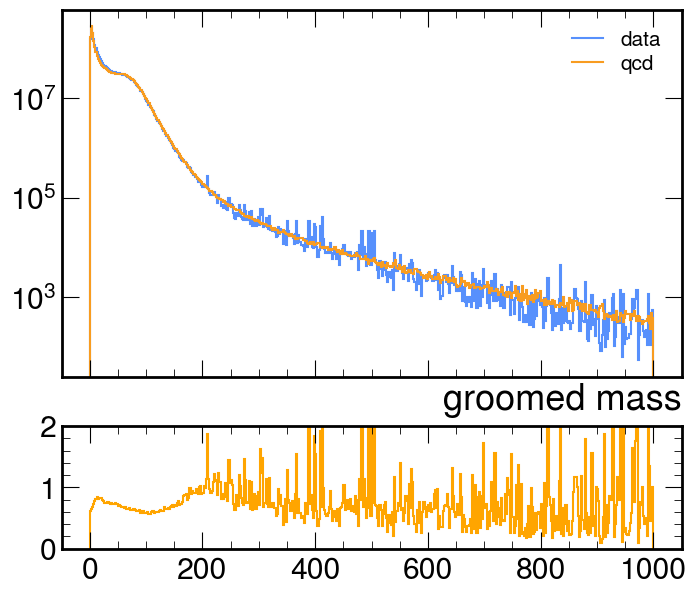

In [23]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["ptreco_mreco_fine_u"].project("mass").axes[0]] + [result["ptreco_mreco_fine_u"].project('mass').axes[0][-1][1]]
edges1 = [bin[0] for bin in result_noxs["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("mass").axes[0]] + [result_noxs["ptreco_mreco_fine_g"].project('mass').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("mass").values()
hist_mc_noxs = result_noxs["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("mass").values()
# hist_mc_noxs1 = result["sdmass_orig"].project("mass").values()
# hist_mc_noxs2 = result["sdmass_ak4corr"].project("mass").values()
hist_mc = result["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("mass").values()
n_data = np.sum(hist_data)
# hist_mc_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
# hist_mc_noxs1 = hist_mc_noxs1*n_data/np.sum(hist_mc_noxs1)
# hist_mc_noxs2 = hist_mc_noxs2*n_data/np.sum(hist_mc_noxs2)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
# ratio = hist_data/hist_mc
ratio1 = hist_data/hist_mc_noxs
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
# ax.set_xlim(10,400)
rax.set_ylim(0,2)
ax.set_yscale('log')
# hep.histplot(ratio, edges1,ax=rax, color='orange')
ax.set_xlabel("groomed mass")
hep.histplot(ratio1, edges1,ax=rax, color='orange')
hep.histplot(hist_data, edges1, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc, edges, binwnorm=True, label="qcd", ax=ax, stack=False)
# hep.histplot(hist_mc_noxs, edges1, binwnorm=True, label="qcd lhe weights", ax=ax, stack=False)
# hep.histplot(hist_mc_noxs1, edges, binwnorm=True, label="no cuts no mass corr", ax=ax, stack=False)
# hep.histplot(hist_mc_noxs2, edges, binwnorm=True, label="no cuts", ax=ax, stack=False)
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

Hist(
  StrCategory(['/QCD_HpythiaMG2018'], growth=True, name='dataset', label='Primary dataset'),
  StrCategory(['nominal', 'LuminosityDown', 'PUSFDown', 'Q2muRUp', 'L1prefiringUp', 'Q2muFUp', 'PDFUp', 'PDFDown', 'PUSFUp', 'LuminosityUp', 'L1prefiringDown', 'Q2muFDown', 'Q2muRDown'], growth=True, name='syst', label='Systematic'),
  IntCategory([-1], growth=True, name='jk', label='Jackknife section'),
  Variable([0, 200, 290, 400, 480, 570, 680, 760, 13000], name='ptreco', label='$p_{T,RECO}$ [GeV]'),
  Variable(array([   0. ,    2.5,    5. ,    7.5,   10. ,   15. ,   20. ,   30. ,
         40. ,   50. ,   60. ,   70. ,   80. ,   90. ,  100. ,  110. ,
        120. ,  130. ,  140. ,  150. ,  160. ,  170. ,  180. ,  190. ,
        200. ,  250. ,  300. ,  350. ,  400. ,  450. ,  500. ,  700. ,
        900. , 1100. , 1300. ]), name='mreco', label='$m_{RECO}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=6.50625e+10, variance=1.08813e+13) (WeightedSum(value=6.50625e+10, variance=1.0

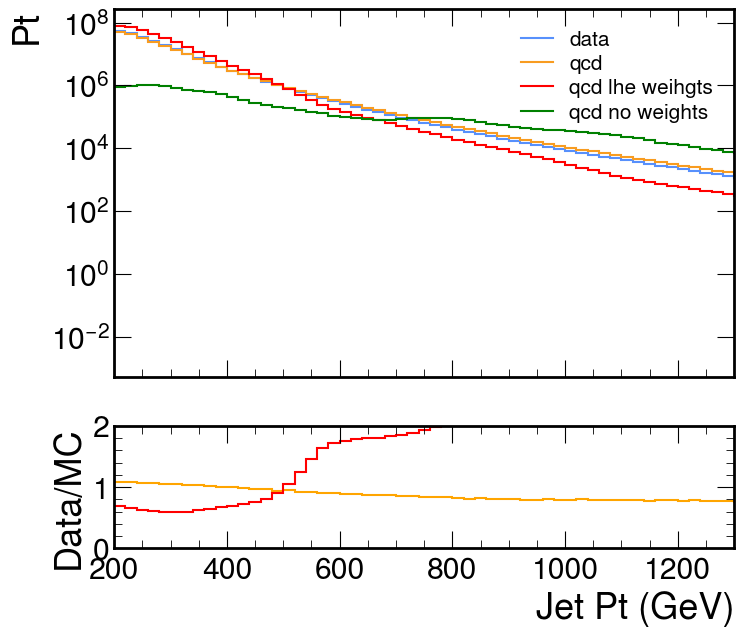

In [32]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["ptreco_mreco_fine_u"].project("pt").axes[0]] + [result["ptreco_mreco_fine_u"].project('pt').axes[0][-1][1]]
edges1 = [bin[0] for bin in result_noxs["ptreco_mreco_fine_g"][{'syst':'nominal'}].project("pt").axes[0]] + [result_noxs["ptreco_mreco_fine_g"].project('pt').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").values()
hist_mc_noxs = result_noxs["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").values()
hist_mc_noxs1 = result_noxs["sdmass_orig"].project("pt").values()
hist_mc = result["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("pt").values()
n_data = np.sum(hist_data)
# hist_mc_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
# hist_mc_noxs1 = hist_mc_noxs1*n_data/np.sum(hist_mc_noxs1)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
ratio = hist_data/hist_mc
ratio1 = hist_data/hist_mc_noxs
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
ax.set_xlim(200,1300)
rax.set_ylim(0,2)
rax.set_ylabel("Data/MC")
rax.set_xlabel("Jet Pt (GeV)")
ax.set_ylabel("Pt")
ax.set_yscale('log')
hep.histplot(ratio, edges,ax=rax, color='orange')
hep.histplot(ratio1, edges,ax=rax, color='red')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc, edges, binwnorm=True, label="qcd", ax=ax, stack=False)
hep.histplot(hist_mc_noxs, edges1, binwnorm=True, label="qcd lhe weihgts", ax=ax, stack=False, color='red')
hep.histplot(hist_mc_noxs1, edges1, binwnorm=True, label="qcd no weights", ax=ax, stack=False, color="green")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
edges = [bin[0] for bin in result["ptreco_mreco_fine_u"].project("mass").axes[0]] + [result["ptreco_mreco_fine_u"].project('mass').axes[0][-1][1]]

edges_data = [bin[0] for bin in result_data["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("mass").axes[0]] + [result["ptreco_mreco_fine_u"].project('mass').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("mass").values()
hist_mc_noxs = result_noxs["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("mass").values()
hist_mc_noxs1 = result["mass_orig"].project("mass").values()
hist_mc = result["ptreco_mreco_fine_u"][{'syst':'nominal'}].project("mass").values()
n_data = np.sum(hist_data)
hist_mc_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
hist_mc_noxs1 = hist_mc_noxs1*n_data/np.sum(hist_mc_noxs1)
hist_mc = hist_mc*n_data/np.sum(hist_mc)
ratio = hist_data/hist_mc
ratio1 = hist_data/hist_mc_noxs
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
ax.set_xlim(0,400)
rax.set_ylim(0,5)
ax.set_yscale('log')
ax.set_xlabel('Ungroomed mass')
hep.histplot(ratio, edges,ax=rax, color='orange')
hep.histplot(ratio1, edges,ax=rax, color='red')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc, edges, binwnorm=True, label="qcd w/ xs", ax=ax, stack=False)
hep.histplot(hist_mc_noxs, edges, binwnorm=True, label="QCD lhe weights", ax=ax, stack=False)
hep.histplot(hist_mc_noxs1, edges, binwnorm=True, label="QCD no weights", ax=ax, stack=False, color="green")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
print(result.keys())
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["sdmass_orig"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["sdmass_orig"].project("pt").axes[0]] + [result["sdmass_orig"].project('pt').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["sdmass_orig"].project("pt").axes[0]] + [result["sdmass_orig"].project('pt').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["sdmass_orig"].project("pt").values()
hist_mc_noxs = result_noxs["sdmass_orig"].project("pt").values()
hist_mc = result["sdmass_orig"].project("pt").values()
# n_data = np.sum(hist_data)
# hist_mc_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
# hist_mc = hist_mc*n_data/np.sum(hist_mc)
ratio = hist_data/hist_mc
ratio1 = hist_data/hist_mc_noxs
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
# ax.set_xlim(0,1300)

ax.set_yscale('log')
hep.histplot(ratio, edges,ax=rax, color='orange')
hep.histplot(ratio1, edges,ax=rax, color='red')
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc, edges, binwnorm=True, label="qcd", ax=ax, stack=False, color="orange")
hep.histplot(hist_mc_noxs, edges, binwnorm=True, label="qcd no xs", ax=ax, stack=False, color="red")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
print(result["ptreco_mreco_u"])
print(result_data["ptreco_mreco_u"])
edges = [bin[0] for bin in result["ptreco_mreco_u"].project("ptreco").axes[0]] + [result["ptreco_mreco_u"].project('ptreco').axes[0][-1][1]]
print(edges)
edges_data = [bin[0] for bin in result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").axes[0]] + [result["ptreco_mreco_u"].project('ptreco').axes[0][-1][1]]
print(edges_data)
print(result_data.keys())
hist_data = result_data["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
hist_mc = result["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
hist_mc_noxs = result_noxs["ptreco_mreco_u"][{'syst':'nominal'}].project("ptreco").values()
n_data = np.sum(hist_data)
hist_mc = hist_mc*n_data/np.sum(hist_mc)
hist_noxs = hist_mc_noxs*n_data/np.sum(hist_mc_noxs)
ratio = hist_data/hist_noxs
print(len(hist_mc))
print(len(hist_data))
print(len(hist_mc_noxs))
ax.set_xlim(0,1300)

ax.set_yscale('log')
hep.histplot(ratio, edges,ax=rax)
hep.histplot(hist_mc, edges, binwnorm=True, ax=ax, label = "qcd", stack=False)
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
hep.histplot(hist_mc_noxs, edges, binwnorm=True, label="qcd no xs", ax=ax, stack=False)
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
mc_hists = []
axVar = "ptreco"
hist_data = result_data["ptreco_mreco_u"].project("ptreco").values()
n_data = np.sum(result_data["ptreco_mreco_u"].project("ptreco").values(),axis=0)
print(n_data)
edges = [bin[0] for bin in result["ptreco_mreco_u"].project("ptreco").axes[0]] + [result["ptreco_mreco_u"].project('ptreco').axes[0][-1][1]]
for i in range(len(results)):
    result = results[i]
    hist = result["ptreco_mreco_u"].project("ptreco").values()
    mc_hists.append(hist)
n_mc = np.sum(np.sum(mc_hists, axis=0))
mc_stack = np.sum(mc_hists, axis=0)*n_data/n_mc

fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
for i in range(len(results)):
    result = results[i]
    hist = result["ptreco_mreco_u"].project("ptreco")*n_data/n_mc
    hep.histplot(hist, binwnorm=True, label="MC "+result_str[i], ax=ax, stack=True)
    ax.set_xlim(0,1300)
    ax.set_yscale('log')
ratio = hist_data/mc_stack
hep.histplot(ratio, edges, ax=rax, stack=False)
hep.histplot(hist_data, edges, binwnorm=True, label="data", ax=ax, stack=False)
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

mc_hists = []
edges = [bin[0] for bin in result["ptreco_mreco_g"].project("mreco").axes[0]] + [result["ptreco_mreco_g"].project('mreco').axes[0][-1][1]]
for i in range(len(results)):
    result = results[i]
    hist = result["ptreco_mreco_g"].project("mreco").values()
    mc_hists.append(hist)
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
for i in range(len(results)):
    result = results[i]
    hist = result["ptreco_mreco_g"].project("mreco")
    hep.histplot(hist, binwnorm=True, label="MC "+result_str[i], ax=ax, stack = True)
    ax.set_xlim(0,1300)
    ax.set_yscale('log')

hist = result_data["ptreco_mreco_g"].project("mreco")
hep.histplot(hist, binwnorm=True, label="data", ax=ax, stack=False)
# mc_stack = np.sum(mc_hists, axis=0)
# ratio = hist.values()/mc_stack
# hep.histplot(ratio, edges, binwnorm=True, ax=rax, stack=False)

leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)

In [ ]:
print(result["MET_over_sumET_pt_reco"])
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
for i in range(len(results)):
    result = results[i]
    hist = result["MET_pt_reco"].project("pt")
    hep.histplot(hist, binwnorm=True, label="MC "+result_str[i], ax=ax, stack=True)
    ax.set_xlim(0,1300)
    ax.set_yscale('log')
ax.set_xlabel("")
rax.set_xlabel("MET (GeV)")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)
fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(8,7),
            gridspec_kw={"height_ratios": (3, 1)},
            sharex=True)
for i in range(len(results)):
    result = results[i]
    hist = result["MET_over_sumET_pt_reco"].project("frac")
    hep.histplot(hist, binwnorm=True, label="MC "+result_str[i], ax=ax, stack = True)
    ax.set_yscale('log')
ax.set_xlabel("")
rax.set_xlabel("MET/Sum_ET")
leg = ax.legend(loc='upper right', labelspacing=0.25, fontsize='xx-small')
leg.set_visible(True)